# NB04: Transferable Feature Engineering

Select optimal shared feature subset with low VIF and high correlation with outcome.

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = '/Users/dlau/repos/fish-welfare/data/'
OUT_DIR = '/Users/dlau/repos/fish-welfare/ModelSelection/'
print("Imports OK")

Imports OK


## 1. Load Target Daily Features

In [2]:
try:
    target_daily = pd.read_csv(DATA_DIR + 'nb01_target_daily_features.csv', parse_dates=['date'])
    print("Loaded nb01_target_daily_features.csv:", target_daily.shape)
except FileNotFoundError:
    print("nb01 file not found, recomputing...")
    # Fallback: recompute from raw data
    import warnings
    warnings.filterwarnings('ignore')
    meteo = pd.read_csv(DATA_DIR + 'open_meteo_24.csv')
    meteo['time'] = pd.to_datetime(meteo['time'])
    meteo = meteo[meteo['region'] == 'Eluru'].copy()
    meteo['date'] = pd.to_datetime(meteo['time'].dt.date)
    meteo['hour'] = meteo['time'].dt.hour
    target_daily = meteo.groupby('date').agg(
        overnight_temp_mean=('temperature_2m','mean'),
        am_vpd_mean=('vapor_pressure_deficit','mean'),
        am_pressure_mean=('surface_pressure','mean'),
        night_precip_sum=('precipitation','sum'),
        night_wind_min=('wind_speed_10m','min'),
        prev_day_temp_max=('temperature_2m','max'),
        diurnal_temp_range=('temperature_2m', lambda x: x.max()-x.min()),
    ).reset_index()
    target_daily['date'] = pd.to_datetime(target_daily['date'])

print("Columns:", target_daily.columns.tolist())
print(target_daily.head(2))

Loaded nb01_target_daily_features.csv: (1707, 24)
Columns: ['date', 'overnight_temp_mean', 'am_vpd_mean', 'am_pressure_mean', 'night_precip_sum', 'night_wind_min', 'prev_day_temp_max', 'prev_day_et0_sum', 'sw_sum_lag1', 'eve_wind_mean', 'diurnal_temp_range', 'eve_cloud_frac', 'doy_cos', 'month_sin', 'roll3d_temp_range', 'roll3d_rh_mean', 'roll3d_wind_mean', 'precip_2d_sum', 'n_total', 'n_low', 'frac_low', 'bad_day', 'mean_do', 'log_n_ponds']
        date  overnight_temp_mean  am_vpd_mean  am_pressure_mean  \
0 2021-06-15               27.800     1.296667        999.033333   
1 2021-06-16               28.675     1.160000       1000.533333   

   night_precip_sum  night_wind_min  prev_day_temp_max  prev_day_et0_sum  \
0               0.3            10.5                NaN               NaN   
1               0.0             4.0               33.3              4.48   

   sw_sum_lag1  eve_wind_mean  ...  roll3d_temp_range  roll3d_rh_mean  \
0          NaN       5.800000  ...             

## 2. Compute Binomial Outcome for Target

In [3]:
wq = pd.read_csv(DATA_DIR + 'water_quality.csv')
target_wq = wq[
    (wq['region'] == 'Eluru') &
    (wq['Type'] == 'Morning') &
    (wq['Is follow up'] == 'No')
].copy()
target_wq['date'] = pd.to_datetime(target_wq['Date of data collection'], format='%m/%d/%Y')
target_wq['DO'] = pd.to_numeric(target_wq['DO (mg/L)'], errors='coerce')
target_wq = target_wq.dropna(subset=['DO'])

daily_out = target_wq.groupby('date').agg(
    n_total=('DO','count'),
    n_low=('DO', lambda x: (x < 3.0).sum()),
    mean_do=('DO','mean')
).reset_index()
daily_out['frac_low'] = daily_out['n_low'] / daily_out['n_total']
daily_out['bad_day'] = (daily_out['frac_low'] >= 0.5).astype(int)
daily_out['log_n_ponds'] = np.log1p(daily_out['n_total'])

# Merge with weather features
# Drop outcome cols from target_daily if they already exist (from NB01)
drop_cols = [c for c in ['n_total','n_low','frac_low','bad_day','mean_do','log_n_ponds'] 
             if c in target_daily.columns]
target_daily_wx = target_daily.drop(columns=drop_cols, errors='ignore')
tgt = target_daily_wx.merge(daily_out, on='date', how='inner')
print("Merged target shape (obs days only):", tgt.shape)
print("frac_low stats:", tgt['frac_low'].describe().round(3).to_dict())

Merged target shape (obs days only): (746, 24)
frac_low stats: {'count': 746.0, 'mean': 0.161, 'std': 0.295, 'min': 0.0, '25%': 0.0, '50%': 0.0, '75%': 0.223, 'max': 1.0}


## 3. Load Source Domain

In [4]:
# SOURCE_LOW_DO_THRESHOLD = 2.176

source = pd.read_csv(DATA_DIR + 'feature_matrix.csv', parse_dates=['date'])
print("Source shape:", source.shape)
print("Source columns:", source.columns.tolist())


Source shape: (53, 30)
Source columns: ['date', 'mean_do', 'frac_low', 'bad_day', 'n_ponds', 'prev_day_et0_sum', 'sw_sum_lag1', 'hist_ph_q25', 'doy_cos', 'hist_ph_mean', 'log_n_ponds', 'month_sin', 'night_precip_sum', 'hist_wtemp_slope', 'am_vpd_mean', 'hist_morning_do_mean', 'roll3d_temp_range', 'hist_do_std', 'prev_day_temp_max', 'night_wind_min', 'hist_wtemp_std', 'hist_wtemp_mean', 'diurnal_temp_range', 'eve_wind_mean', 'roll3d_wind_mean', 'roll3d_rh_mean', 'precip_2d_sum', 'overnight_temp_mean', 'eve_cloud_frac', 'am_pressure_mean']


In [5]:
deciles = source['frac_low'].dropna().quantile(np.arange(0,1.1,0.1))
print(deciles.round(3))

0.0    0.000
0.1    0.213
0.2    0.321
0.3    0.394
0.4    0.438
0.5    0.467
0.6    0.534
0.7    0.562
0.8    0.615
0.9    0.643
1.0    0.800
Name: frac_low, dtype: float64


## 4. Spearman Correlations: Features vs frac_low (Target)

In [6]:
shared_features = [
    'overnight_temp_mean', 'am_vpd_mean', 'am_pressure_mean',
    'night_precip_sum', 'night_wind_min', 'prev_day_temp_max',
    'prev_day_et0_sum', 'sw_sum_lag1', 'eve_wind_mean',
    'diurnal_temp_range', 'eve_cloud_frac', 'doy_cos', 'month_sin',
    'roll3d_temp_range', 'roll3d_rh_mean', 'roll3d_wind_mean',
    'precip_2d_sum', 'log_n_ponds'
]

spearman_rows = []
for f in shared_features:
    if f not in tgt.columns:
        continue
    xy = tgt[['frac_low', f]].dropna()
    if len(xy) < 10:
        continue
    r_sp, p_sp = stats.spearmanr(xy[f], xy['frac_low'])
    r_pe, p_pe = stats.pearsonr(xy[f], xy['frac_low'])
    spearman_rows.append({
        'feature': f, 
        'spearman_r': round(r_sp, 3), 
        'spearman_p': round(p_sp, 4),
        'pearson_r': round(r_pe, 3),
        'n_obs': len(xy)
    })

corr_df = pd.DataFrame(spearman_rows).sort_values('spearman_r', key=abs, ascending=False)
print("Feature correlations with frac_low (target domain):")
print(corr_df.to_string(index=False))

Feature correlations with frac_low (target domain):
            feature  spearman_r  spearman_p  pearson_r  n_obs
          month_sin      -0.168      0.0000     -0.183    746
   night_precip_sum       0.105      0.0042      0.099    746
      eve_wind_mean      -0.104      0.0043     -0.083    746
 diurnal_temp_range      -0.099      0.0066     -0.120    746
      precip_2d_sum       0.087      0.0177      0.109    746
  roll3d_temp_range      -0.087      0.0177     -0.096    746
            doy_cos      -0.077      0.0355     -0.128    746
   am_pressure_mean      -0.062      0.0923     -0.104    746
   roll3d_wind_mean      -0.060      0.1026     -0.012    746
   prev_day_et0_sum      -0.053      0.1447     -0.011    746
     roll3d_rh_mean       0.050      0.1720      0.028    746
        sw_sum_lag1      -0.045      0.2238     -0.025    746
        log_n_ponds       0.044      0.2318     -0.088    746
        am_vpd_mean      -0.035      0.3378      0.033    746
  prev_day_temp_ma

## 5. Compare Source vs Target Correlations

In [7]:
src_corr_rows = []
for f in shared_features:
    if f not in source.columns:
        continue
    xy = source[['frac_low', f]].dropna()
    if len(xy) < 5:
        continue
    r_sp, p_sp = stats.spearmanr(xy[f], xy['frac_low'])
    src_corr_rows.append({'feature': f, 'src_spearman_r': round(r_sp, 3)})

src_corr_df = pd.DataFrame(src_corr_rows)
compare_df = corr_df.merge(src_corr_df, on='feature', how='left')
compare_df['agreement'] = np.sign(compare_df['spearman_r']) == np.sign(compare_df['src_spearman_r'])
print("Source vs Target correlation comparison:")
print(compare_df[['feature','spearman_r','src_spearman_r','agreement']].to_string(index=False))

Source vs Target correlation comparison:
            feature  spearman_r  src_spearman_r  agreement
          month_sin      -0.168           0.279      False
   night_precip_sum       0.105           0.218       True
      eve_wind_mean      -0.104          -0.078       True
 diurnal_temp_range      -0.099          -0.025       True
      precip_2d_sum       0.087           0.073       True
  roll3d_temp_range      -0.087          -0.042       True
            doy_cos      -0.077           0.333      False
   am_pressure_mean      -0.062           0.002      False
   roll3d_wind_mean      -0.060          -0.037       True
   prev_day_et0_sum      -0.053          -0.210       True
     roll3d_rh_mean       0.050           0.079       True
        sw_sum_lag1      -0.045          -0.290       True
        log_n_ponds       0.044           0.352       True
        am_vpd_mean      -0.035          -0.261       True
  prev_day_temp_max      -0.032           0.053      False
     night_wind

## 6. VIF Analysis

In [8]:
candidate_features = [f for f in shared_features if f in tgt.columns]
X_vif = tgt[candidate_features].dropna()
print(f"Rows for VIF analysis: {len(X_vif)}")

vif_data = pd.DataFrame()
vif_data["feature"] = candidate_features
vif_values = []
for i, col in enumerate(candidate_features):
    try:
        Xmat = X_vif.values
        vif = variance_inflation_factor(Xmat, i)
    except:
        vif = np.nan
    vif_values.append(round(vif, 2))
vif_data["VIF"] = vif_values
vif_data = vif_data.sort_values('VIF', ascending=False)
print("\nVIF values:")
print(vif_data.to_string(index=False))

Rows for VIF analysis: 746

VIF values:
            feature     VIF
   am_pressure_mean 3059.68
     eve_cloud_frac 2762.14
  prev_day_temp_max 2251.85
overnight_temp_mean 1491.86
   prev_day_et0_sum  569.77
     roll3d_rh_mean  466.12
        sw_sum_lag1  410.05
  roll3d_temp_range  274.15
 diurnal_temp_range  109.90
   roll3d_wind_mean   49.59
      eve_wind_mean   15.72
        am_vpd_mean   15.40
        log_n_ponds   12.91
            doy_cos    8.91
     night_wind_min    8.69
      precip_2d_sum    4.10
          month_sin    3.35
   night_precip_sum    2.19


## 7. Select Optimal Feature Subset

In [9]:
# Select: low VIF (<5 preferred), high |Spearman|, available in both domains
merged = corr_df.merge(vif_data, on='feature', how='left').merge(
    compare_df[['feature','src_spearman_r','agreement']], on='feature', how='left'
)
merged['abs_spearman'] = merged['spearman_r'].abs()
merged['in_source'] = merged['feature'].isin(source.columns)

# Score: high abs_spearman + low VIF + in source
merged['score'] = merged['abs_spearman'] / (merged['VIF'].fillna(10) / 5.0)

merged_sorted = merged.sort_values('score', ascending=False)
print("Feature selection scores:")
print(merged_sorted[['feature','spearman_r','src_spearman_r','VIF','in_source','score']].to_string(index=False))

# Select top features with VIF < 5 or VIF < 10 (relaxed)
selected = merged_sorted[
    (merged_sorted['in_source'] == True) &
    (merged_sorted['VIF'].fillna(100) < 10) &
    (merged_sorted['abs_spearman'] > 0.0)
].head(12)['feature'].tolist()

print(f"\nSelected {len(selected)} features:")
for f in selected:
    row = merged_sorted[merged_sorted['feature']==f].iloc[0]
    print(f"  {f}: spearman={row['spearman_r']:.3f}, VIF={row['VIF']:.1f}")

Feature selection scores:
            feature  spearman_r  src_spearman_r     VIF  in_source    score
          month_sin      -0.168           0.279    3.35       True 0.250746
   night_precip_sum       0.105           0.218    2.19       True 0.239726
      precip_2d_sum       0.087           0.073    4.10       True 0.106098
            doy_cos      -0.077           0.333    8.91       True 0.043210
      eve_wind_mean      -0.104          -0.078   15.72       True 0.033079
     night_wind_min      -0.031          -0.091    8.69       True 0.017837
        log_n_ponds       0.044           0.352   12.91       True 0.017041
        am_vpd_mean      -0.035          -0.261   15.40       True 0.011364
   roll3d_wind_mean      -0.060          -0.037   49.59       True 0.006050
 diurnal_temp_range      -0.099          -0.025  109.90       True 0.004504
  roll3d_temp_range      -0.087          -0.042  274.15       True 0.001587
        sw_sum_lag1      -0.045          -0.290  410.05       

## 8. Plots: Correlation Heatmap, VIF, Scatter Plots

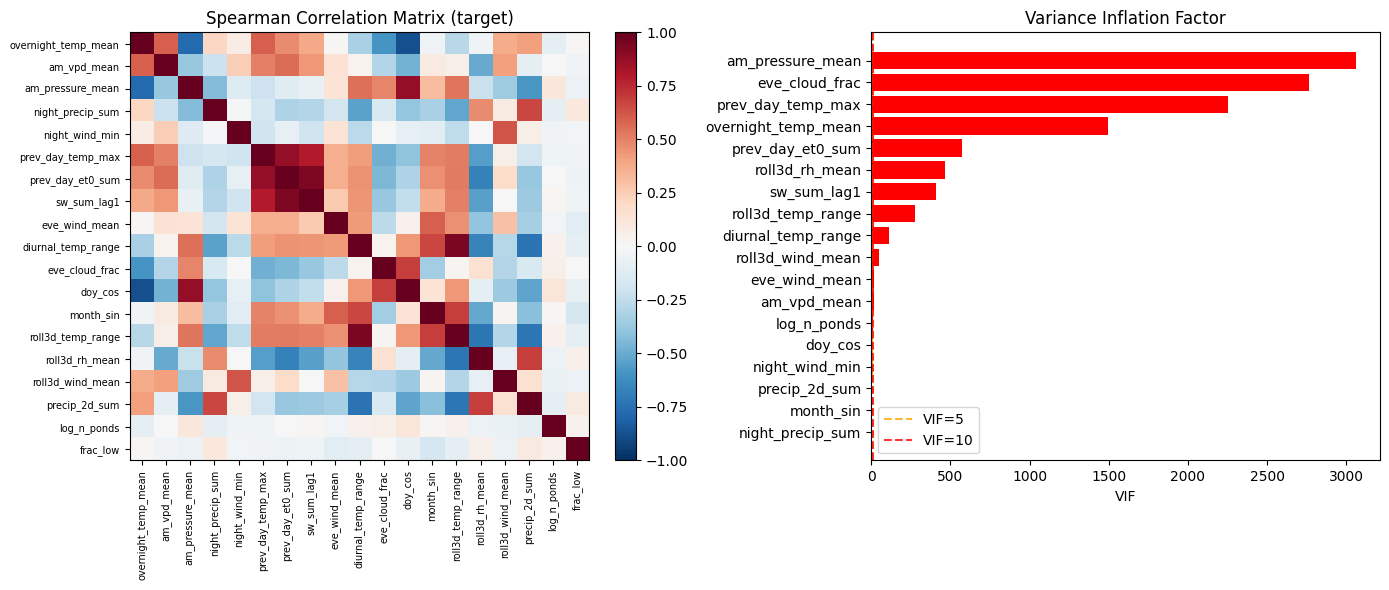

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Correlation heatmap
ax = axes[0]
feat_avail = [f for f in shared_features if f in tgt.columns and len(tgt[f].dropna()) > 10]
corr_matrix = tgt[feat_avail + ['frac_low']].corr(method='spearman')
im = ax.imshow(corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=90, fontsize=7)
ax.set_yticklabels(corr_matrix.columns, fontsize=7)
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_title('Spearman Correlation Matrix (target)')

# VIF bar chart
ax = axes[1]
plot_vif = vif_data.sort_values('VIF', ascending=True)
colors_vif = ['red' if v > 10 else ('orange' if v > 5 else 'steelblue') for v in plot_vif['VIF']]
ax.barh(plot_vif['feature'], plot_vif['VIF'], color=colors_vif)
ax.axvline(5, color='orange', linestyle='--', alpha=0.8, label='VIF=5')
ax.axvline(10, color='red', linestyle='--', alpha=0.8, label='VIF=10')
ax.set_xlabel('VIF')
ax.set_title('Variance Inflation Factor')
ax.legend()

plt.tight_layout()
plt.savefig(OUT_DIR + 'nb04_feature_selection.png', dpi=80, bbox_inches='tight')
plt.show()

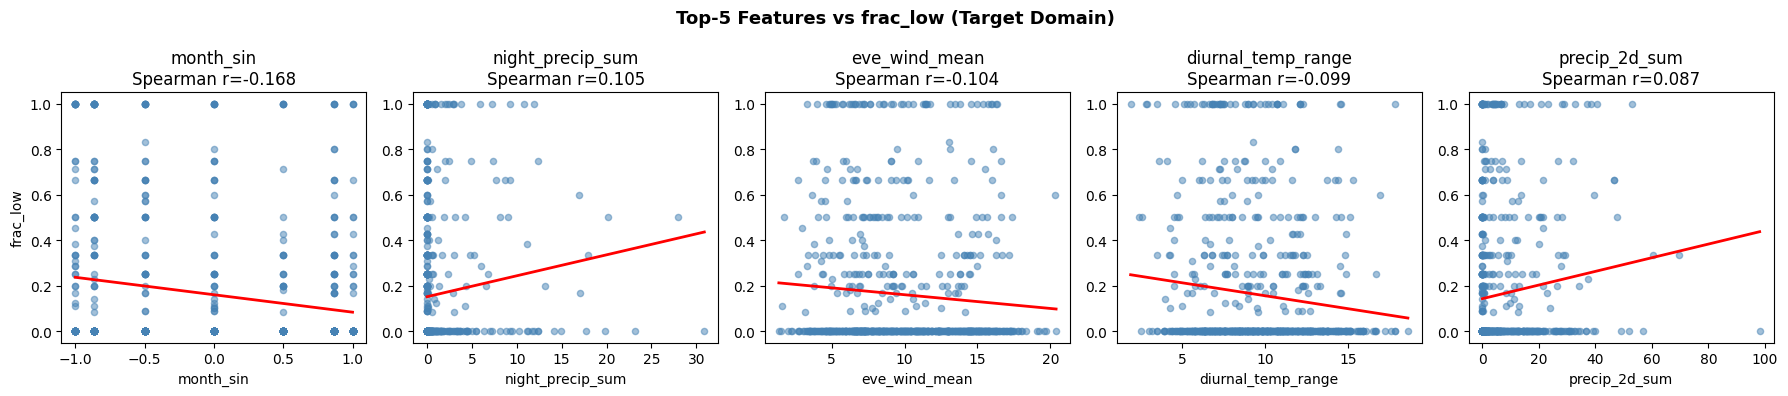

In [11]:
# Scatter plots for top-5 features
top5 = corr_df.sort_values('spearman_r', key=abs, ascending=False).head(5)['feature'].tolist()
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for i, f in enumerate(top5):
    ax = axes[i]
    xy = tgt[['frac_low', f]].dropna()
    ax.scatter(xy[f], xy['frac_low'], alpha=0.5, s=20, color='steelblue')
    m, b = np.polyfit(xy[f], xy['frac_low'], 1)
    ax.plot(np.sort(xy[f]), m * np.sort(xy[f]) + b, 'r-', linewidth=2)
    r = corr_df[corr_df['feature']==f]['spearman_r'].values
    ax.set_title(f"{f}\nSpearman r={r[0]:.3f}" if len(r) > 0 else f)
    ax.set_xlabel(f)
    if i == 0:
        ax.set_ylabel('frac_low')

plt.suptitle('Top-5 Features vs frac_low (Target Domain)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR + 'nb04_top5_scatter.png', dpi=80, bbox_inches='tight')
plt.show()

## 9. Save Feature Matrices

In [12]:
# Source feature matrix (with selected features)
src_feats_avail = [f for f in selected if f in source.columns]
source_out = source[['date','mean_do','frac_low','bad_day','n_ponds'] + src_feats_avail].copy()
source_out['log_n_ponds'] = np.log1p(source_out['n_ponds'])
source_out.to_csv(DATA_DIR + 'nb04_source_features.csv', index=False)
print("Saved nb04_source_features.csv:", source_out.shape)

# Target feature matrix
tgt_feats_avail = [f for f in selected if f in tgt.columns]
target_out = tgt[['date','n_total','n_low','frac_low','bad_day','log_n_ponds'] + tgt_feats_avail].copy()
target_out.to_csv(DATA_DIR + 'nb04_target_features.csv', index=False)
print("Saved nb04_target_features.csv:", target_out.shape)

# Save selected features list
import json
with open(DATA_DIR + 'nb04_selected_features.json', 'w') as f:
    json.dump({'selected_features': selected, 'src_available': src_feats_avail, 'tgt_available': tgt_feats_avail}, f, indent=2)
print("Saved nb04_selected_features.json")
print("Selected features:", selected)

Saved nb04_source_features.csv: (53, 11)
Saved nb04_target_features.csv: (746, 11)
Saved nb04_selected_features.json
Selected features: ['month_sin', 'night_precip_sum', 'precip_2d_sum', 'doy_cos', 'night_wind_min']


## Iteration 2: LASSO, Mutual Information, Bootstrap Stability

In [13]:
# ── Iteration 2 setup ──────────────────────────────────────────────────────
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler
import warnings; warnings.filterwarnings('ignore')

DATA_DIR = '/Users/dlau/repos/fish-welfare/data/'
tgt = pd.read_csv(DATA_DIR + 'nb04_target_features.csv', parse_dates=['date'])
features = ['month_sin','night_precip_sum','precip_2d_sum','doy_cos','night_wind_min']

tgt2 = tgt[features + ['frac_low']].dropna()
X = tgt2[features].values; y = tgt2['frac_low'].values
scaler = StandardScaler(); X_s = scaler.fit_transform(X)

# LASSO
lasso = LassoCV(cv=5, max_iter=2000, random_state=42)
lasso.fit(X_s, y)
print("LASSO selected features:")
for f, c in sorted(zip(features, lasso.coef_), key=lambda x: abs(x[1]), reverse=True):
    status = "SELECTED" if abs(c) > 1e-6 else "zeroed"
    print(f"  {f:<22} coef={c:>8.4f}  ({status})")
print(f"  Best alpha: {lasso.alpha_:.4f}")

# Mutual information
mi = mutual_info_regression(X_s, y, random_state=42)
print("\nMutual information (target):")
for f, m in sorted(zip(features, mi), key=lambda x: x[1], reverse=True):
    print(f"  {f:<22} MI={m:.4f}")


LASSO selected features:
  month_sin              coef=  0.0000  (zeroed)
  night_precip_sum       coef=  0.0000  (zeroed)
  precip_2d_sum          coef=  0.0000  (zeroed)
  doy_cos                coef=  0.0000  (zeroed)
  night_wind_min         coef=  0.0000  (zeroed)
  Best alpha: 0.0540

Mutual information (target):
  precip_2d_sum          MI=0.0459
  night_wind_min         MI=0.0299
  doy_cos                MI=0.0264
  month_sin              MI=0.0000
  night_precip_sum       MI=0.0000


Bootstrap stability (fraction selected, n=100):
  month_sin              selected=49%  mean_coef=-0.0044  std=0.0063
  precip_2d_sum          selected=2%  mean_coef= 0.0000  std=0.0004
  night_precip_sum       selected=1%  mean_coef= 0.0000  std=0.0001
  doy_cos                selected=1%  mean_coef=-0.0000  std=0.0001
  night_wind_min         selected=0%  mean_coef= 0.0000  std=0.0000


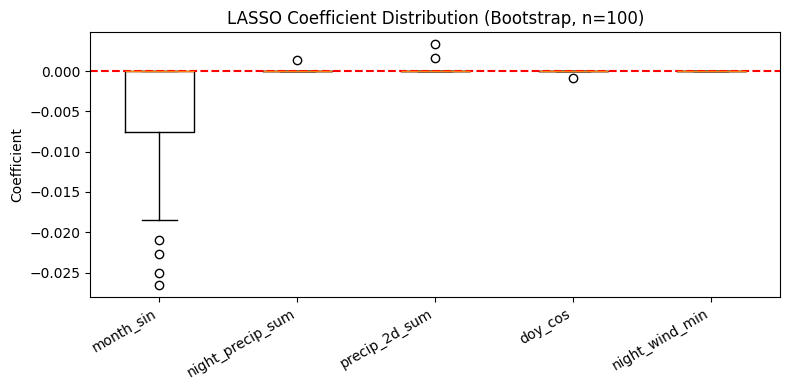

In [14]:
# ── Bootstrap stability ─────────────────────────────────────────────────────
from sklearn.linear_model import Lasso

n_boot = 100
np.random.seed(42)
coefs = np.zeros((n_boot, len(features)))
for i in range(n_boot):
    idx = np.random.choice(len(X_s), len(X_s), replace=True)
    lasso_b = Lasso(alpha=lasso.alpha_, max_iter=2000)
    lasso_b.fit(X_s[idx], y[idx])
    coefs[i] = lasso_b.coef_

stability = (np.abs(coefs) > 1e-6).mean(0)
print("Bootstrap stability (fraction selected, n=100):")
for f, s, mean_c, std_c in sorted(zip(features, stability, coefs.mean(0), coefs.std(0)), key=lambda x: x[1], reverse=True):
    print(f"  {f:<22} selected={s:.0%}  mean_coef={mean_c:>7.4f}  std={std_c:.4f}")

fig, ax = plt.subplots(figsize=(8,4))
ax.boxplot(coefs, labels=features, vert=True)
ax.axhline(0, color='r', linestyle='--')
ax.set_title('LASSO Coefficient Distribution (Bootstrap, n=100)')
ax.set_ylabel('Coefficient')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(DATA_DIR + 'nb04v2_lasso_bootstrap.png', dpi=80, bbox_inches='tight')
plt.show()
